In [1]:
import polars as pl
import numpy as np

import src.data.utils as dutils

In [2]:
PATH = "../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/"
train_df, test_df = dutils.read_data(PATH)
train_df.shape, test_df.shape

C:\Work\Project\cv-architecture-sprint-cifar\src\data\utils.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding='bytes')


((50000, 3), (10000, 3))

In [3]:
train_df.group_by("label_names").len()

label_names,len
str,u32
"""deer""",5000
"""horse""",5000
"""bird""",5000
"""ship""",5000
"""cat""",5000
"""automobile""",5000
"""truck""",5000
"""frog""",5000
"""dog""",5000


In [4]:
import matplotlib.pyplot as plt

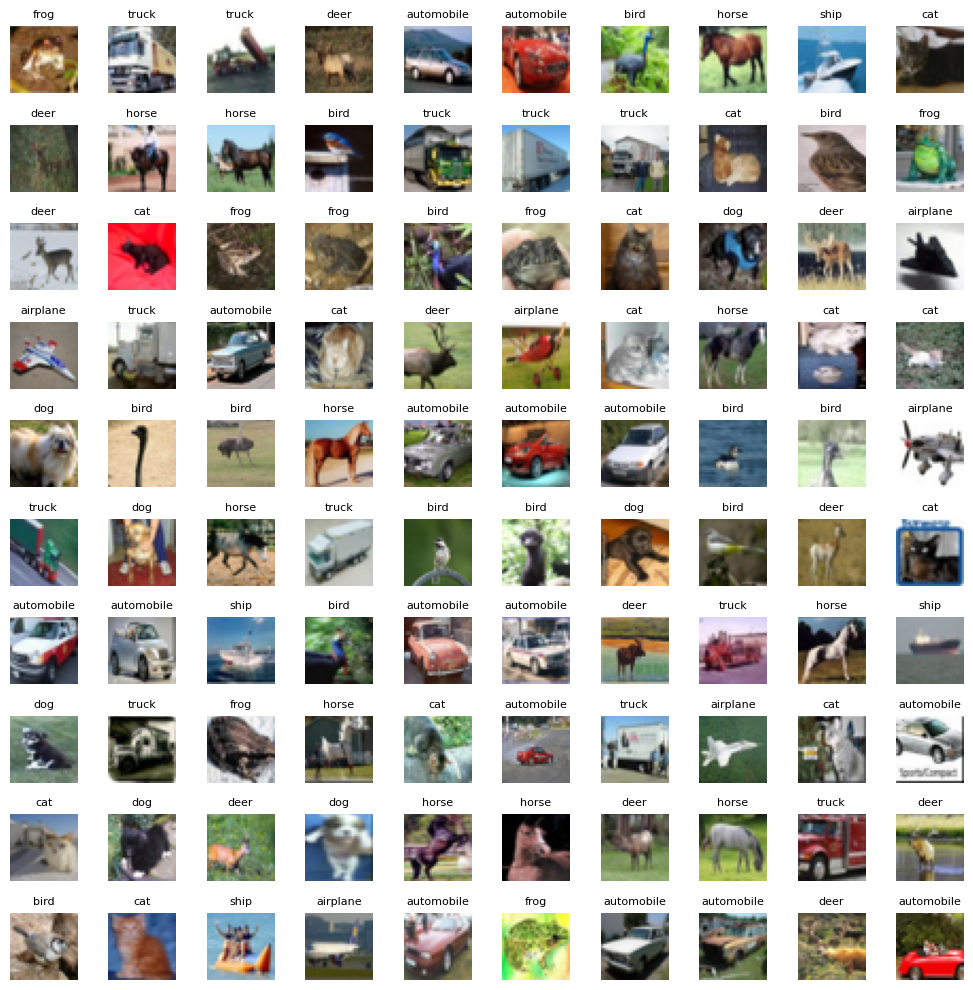

In [51]:
def plot_sample_grid(df, grid_size=10):

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i in range(grid_size * grid_size):
        ax = axes[i // grid_size, i % grid_size]

        ax.imshow(df["data"][i])
        ax.set_title(str(df["label_names"][i]), fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_sample_grid(train_df)

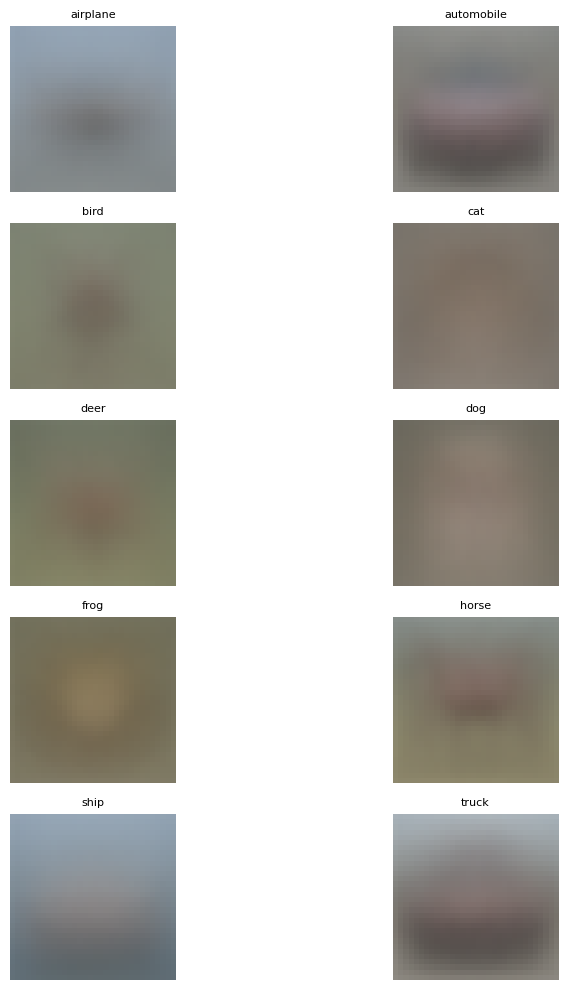

In [50]:
def plot_mean(df):

    fig, axes = plt.subplots(5, 2, figsize=(10, 10))
    for i in range(5 * 2):
        ax = axes[i // 2, i % 2]
        img_data = np.mean(df.filter(pl.col("label") == i).select("data").to_series().to_list(), dtype=np.int64, axis=0)
        label_name = df.filter(pl.col("label") == i).select("label_names").to_series()[0]
        ax.imshow(img_data)
        ax.set_title(label_name,  fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
plot_mean(train_df)

In [46]:
import cv2
gray_img = cv2.cvtColor(train_df["data"][0], cv2.COLOR_BGR2GRAY)

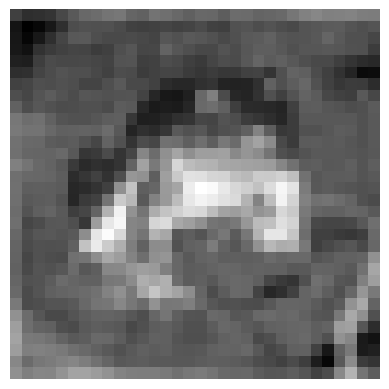

In [49]:
plt.imshow(gray_img, cmap="gray")
plt.axis('off')
# plt.title("Label: " + str(data_dict[b'labels'][0]))
plt.show()

In [41]:
from scipy.stats import gaussian_kde

def plot_pixel_hist(df: pl.DataFrame):
    fig, axes = plt.subplots(5, 2, figsize=(10, 10))
    for i, label in enumerate(df["label"].unique().to_list()):
        red_pixels = []
        green_pixels = []
        blue_pixels = []
        
        ax = axes[i // 2, i % 2]
        
        for data in train_df.filter(pl.col("label") == label)["data"]:
            red_pixels.extend(data[:,:,0].reshape(-1))
            green_pixels.extend(data[:,:,1].reshape(-1))
            blue_pixels.extend(data[:,:,2].reshape(-1))
        ax.hist(red_pixels, color="red", alpha=0.3, bins=50, density=True)
        ax.hist(green_pixels, color="green", alpha=0.3, bins=50, density=True)
        ax.hist(blue_pixels, color="blue", alpha=0.3, bins=50, density=True)
        
                
        kde_red = gaussian_kde(red_pixels)
        kde_green = gaussian_kde(green_pixels)
        kde_blue = gaussian_kde(blue_pixels)
        
        x = np.linspace(0, 256, 256)
        ax.plot(x, kde_red(x), color="red", linewidth=2, label="Red")
        ax.plot(x, kde_green(x), color="green", linewidth=2, label="Green")
        ax.plot(x, kde_blue(x), color="blue", linewidth=2, label="Blue")
        
        label_name = df.filter(pl.col("label") == label).select("label_names").to_series()[0]
        
        ax.set_title(f"{label_name}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Pixel Value", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)
        
    plt.tight_layout()
    plt.show()        

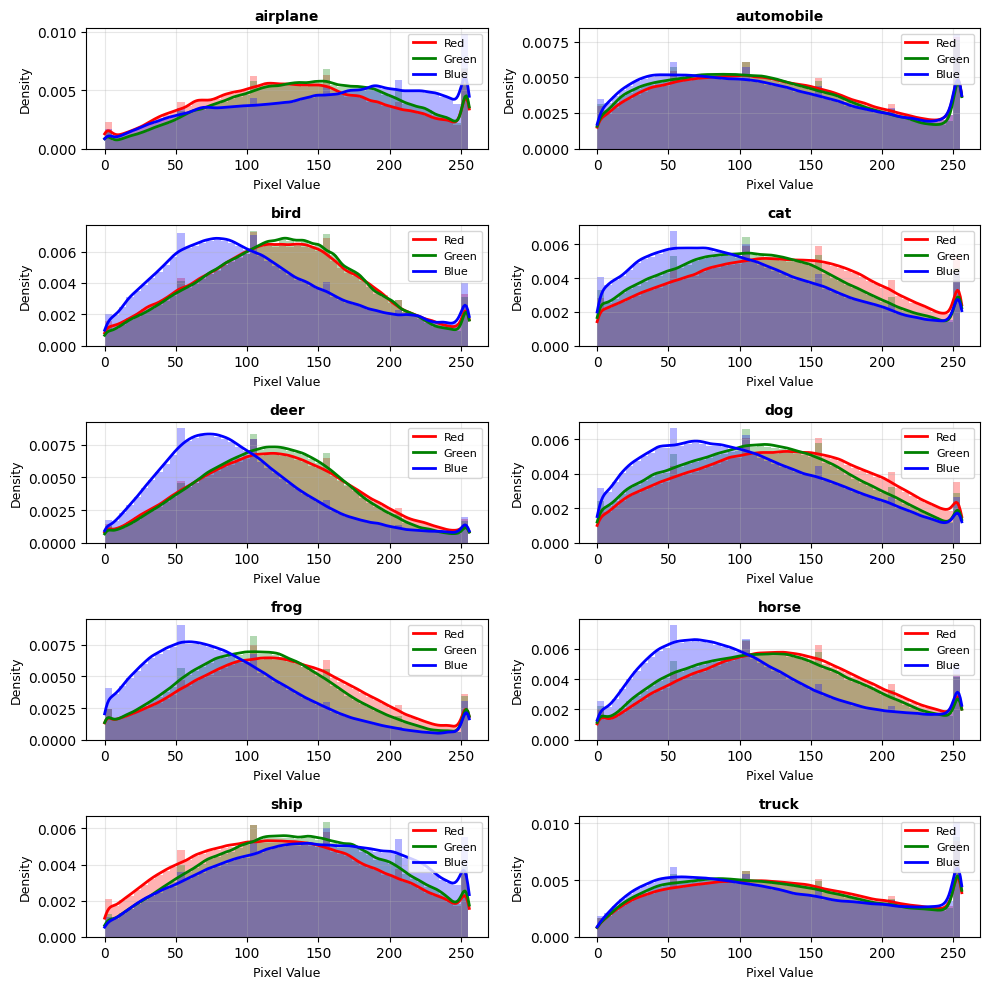

In [42]:
plot_pixel_hist(train_df)

In [18]:
import torch

In [23]:
torch.tensor(np.stack(train_df[0]["data"].to_list()), dtype=torch.float32).shape

torch.Size([1, 32, 32, 3])

In [22]:
all_red = []
all_green = []
all_blue = []
for d in train_df["data"]:
    all_red.extend(d[:,:,0].reshape(-1))
    all_green.extend(d[:,:,1].reshape(-1))
    all_blue.extend(d[:,:,2].reshape(-1))

In [23]:
all_red = np.asarray(all_red).astype(np.float32) / 255.0
all_green = np.asarray(all_green).astype(np.float32) / 255.0
all_blue = np.asarray(all_blue).astype(np.float32) / 255.0

In [24]:
print("Red channel | Mean: ", np.mean(all_red),", STD: ", np.std(all_red, ddof=1))
print("Green channel | Mean: ", np.mean(all_green),", STD: ", np.std(all_green, ddof=1))
print("Blue channel | Mean: ", np.mean(all_blue),", STD: ", np.std(all_blue, ddof=1))

Red channel | Mean:  0.49139968 , STD:  0.24703223
Green channel | Mean:  0.48215845 , STD:  0.24348514
Blue channel | Mean:  0.4465309 , STD:  0.26158786
